## Modelos lineales generalizados

In [1]:
import pandas as pd
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import warnings
import numpy as np
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler


### **Regresión Gaussiana**
La función de enlace es la identidad, lo que implica una relación lineal directa entre la variable dependiente y las predictoras.
De esta forma la se modela Y como una combinación lineal de las variables predictoras.

Error cuadrático medio (MSE): 2.6147980548680105


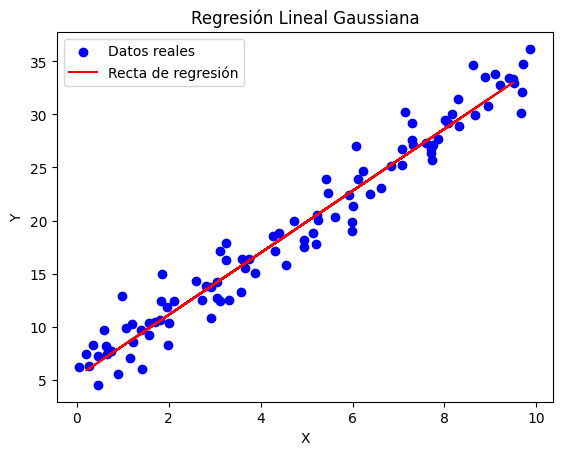

Coeficiente (beta_1): [2.91972946]
Intercepto (beta_0): [5.28582664]


In [2]:
# Ejemplo con datos sintéticos de la implementación de un modelo de regresión Gaussiana

# Generar datos de ejemplo
np.random.seed(42)

# Número de muestras
n = 100

# Variables independientes (X), por ejemplo, un conjunto de datos aleatorios
X = np.random.rand(n, 1) * 10  # 100 puntos entre 0 y 10

# Parámetros de la regresión lineal
beta_0 = 5    # Intercepto
beta_1 = 3    # Coeficiente de X

# Generar valores de Y a partir de la fórmula Y = beta_0 + beta_1 * X + error
error = np.random.normal(0, 2, size=(n, 1))  # Error con distribución normal (media=0, desviación estándar=2)
y = beta_0 + beta_1 * X + error  # La variable dependiente Y

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Hacer predicciones con los datos de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
print(f"Error cuadrático medio (MSE): {mse}")

# Graficar los datos y la recta de regresión
plt.scatter(X, y, color='blue', label='Datos reales')
plt.plot(X_test, y_pred, color='red', label='Recta de regresión')
plt.title('Regresión Lineal Gaussiana')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

# Mostrar los coeficientes aprendidos por el modelo
print(f"Coeficiente (beta_1): {model.coef_[0]}")
print(f"Intercepto (beta_0): {model.intercept_}")

In [3]:
# EJEMPLO CON DATOS DE LAS CUENCAS

gdf = gpd.read_file(r"C:\Users\DAVID01\Documents\GitHub\Geospatial-analysis\ejercicios\df_catchments_spatial.gpkg")
gdf.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   id                   526 non-null    int64   
 1   Nombre               526 non-null    str     
 2   ID_CUENCA            526 non-null    float64 
 3   cuenca               526 non-null    str     
 4   area                 526 non-null    int64   
 5   elev_mean            526 non-null    float64 
 6   elev_median          526 non-null    float64 
 7   rel_mean             526 non-null    float64 
 8   rel_median           526 non-null    float64 
 9   rainfallAnnual_mean  526 non-null    float64 
 10  Densidad             526 non-null    float64 
 11  hypso_inte           526 non-null    float64 
 12  slope_mean           526 non-null    float64 
 13  kmeans               526 non-null    str     
 14  RainfallDaysmean     526 non-null    float64 
 15  RainfallDaysmed

In [4]:
# Preparar datos
gdf["y_log"] = np.log(gdf['lands_rec'] + 1)
var = ['area', 'elev_mean', 'rel_mean']

# Escalar variables
st = StandardScaler()
X_scaled = st.fit_transform(gdf[var])

# Añadir una constante para el término de intercepción en el modelo
X = sm.add_constant(X_scaled)
y = gdf['y_log']

# Entrenar el modelo de regresión lineal
model = sm.OLS(y, X).fit()

# Imprimir un resumen del modelo
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  y_log   R-squared:                       0.499
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     173.6
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           4.62e-78
Time:                        19:57:30   Log-Likelihood:                -800.35
No. Observations:                 526   AIC:                             1609.
Df Residuals:                     522   BIC:                             1626.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8396      0.048     37.931      0.0

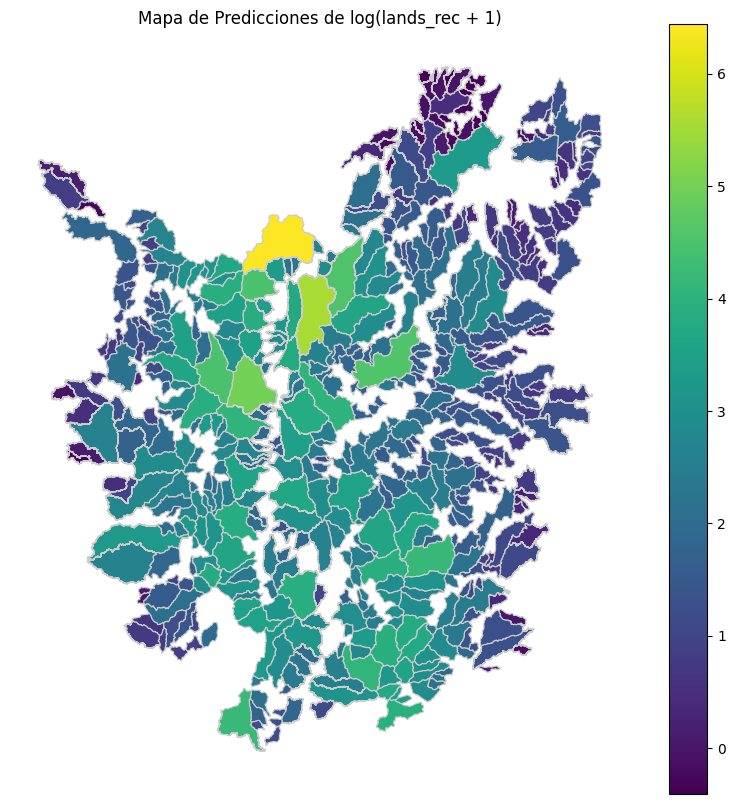

In [5]:
# Obtener las predicciones
y_pred = model.predict(X)

# Añadir las predicciones al GeoDataFrame
gdf['y_pred'] = y_pred

# Graficar el mapa con los valores de predicción
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='y_pred', cmap='viridis', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Mapa de Predicciones de log(lands_rec + 1)')
ax.set_axis_off()
plt.show()

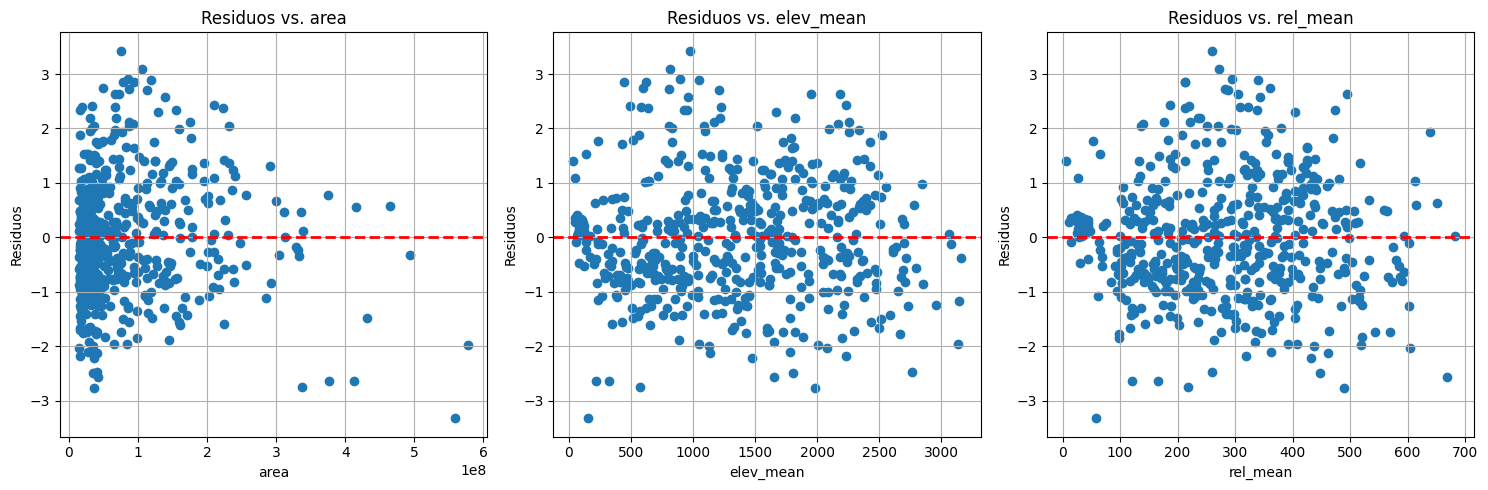

In [6]:
# Calcular los residuos
residuals = y - y_pred

# Crear las figuras scatter para comparar los residuos con cada variable X
plt.figure(figsize=(15, 5))

for i, variable in enumerate(var):
    plt.subplot(1, 3, i + 1)
    plt.scatter(gdf[variable], residuals)
    plt.axhline(y=0, color='r', linestyle='--', lw=2)
    plt.xlabel(variable)
    plt.ylabel('Residuos')
    plt.title(f'Residuos vs. {variable}')
    plt.grid(True)

plt.tight_layout()
plt.show()

### **Distribución binomial (Regresión Logística)**
Se usa para obtener la probabilidad de obtener un número de éxitos en experimentos con dos resultados posibles (éxito o fracaso)

La función de enlace es Logit, correspondiente al logaritmo de los odds, siendo los odds la probabilidad de ocurrencia sobre la probabilidad de no ocurrencia de un evento.

Se dice que el modelo asume una distribución Bernoulli para la respuesta

In [7]:
#EJEMPLO DE AJUSTE DE MODELO LOGISTICO PARA UNA VARIABLE CONTINUA Y UNA BINARIA

import statsmodels.api as sm
import pandas as pd
np.random.seed(0)
n = 500

# Covariables
x1 = np.random.normal(0, 1, n)
x2 = np.random.binomial(1, 0.5, n)

# Coeficientes verdaderos
beta_0 = -0.5
beta_1 = 2.0
beta_2 = -1.0

# Probabilidad con función logística
lin_pred = beta_0 + beta_1 * x1 + beta_2 * x2
p = 1 / (1 + np.exp(-lin_pred))

# Variable respuesta binaria
y = np.random.binomial(1, p)

# DataFrame
df = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})

In [8]:
# Agregar constante
X = sm.add_constant(df[['x1', 'x2']])  # añade la constante (intercepto)
y = df['y']

# Ajuste del modelo
modelo = sm.Logit(y, X).fit()

print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.456092
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  500
Model:                          Logit   Df Residuals:                      497
Method:                           MLE   Df Model:                            2
Date:                Thu, 11 Jun 2026   Pseudo R-squ.:                  0.2995
Time:                        19:57:32   Log-Likelihood:                -228.05
converged:                       True   LL-Null:                       -325.54
Covariance Type:            nonrobust   LLR p-value:                 4.555e-43
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2504      0.153     -1.638      0.101      -0.550       0.049
x1             1.6643      0.

### Ejemplo con datos sintéticos de la implementación de un modelo de regresión logística con sklearn

In [9]:
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

np.random.seed(42)
n = 1000

# Variables predictoras
x1 = np.random.normal(loc=0, scale=1, size=n)
x2 = np.random.normal(loc=2, scale=1.5, size=n)

# Coeficientes reales
beta_0 = -1
beta_1 = 2.0
beta_2 = -1.5

# Lineal predictor
eta = beta_0 + beta_1 * x1 + beta_2 * x2

# Probabilidad con función logística
p = 1 / (1 + np.exp(-eta))

# Variable binaria (respuesta)
y = np.random.binomial(1, p)

# Crear DataFrame
df = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})
df.head()

,x1,x2,y
0,0.496714,4.099033,0
1,-0.138264,3.386951,0
2,0.647689,2.089446,0
3,1.523030,1.029595,1
4,-0.234153,3.047335,0


In [10]:
# Modelo logístico
model = LogisticRegression()
model.fit(df[['x1', 'x2']], df['y'])

# Coeficientes estimados
print("Intercepto:", model.intercept_)
print("Coeficientes:", model.coef_)

Intercepto: [-1.27875569]
Coeficientes: [[ 2.19160475 -1.4779385 ]]


In [11]:
# Predicciones
y_pred = model.predict(df[['x1', 'x2']])
y_prob = model.predict_proba(df[['x1', 'x2']])[:,1] #probabilidad del si

Matriz de confusión:
[[866  17]
 [ 53  64]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       883
           1       0.79      0.55      0.65       117

    accuracy                           0.93      1000
   macro avg       0.87      0.76      0.80      1000
weighted avg       0.92      0.93      0.92      1000



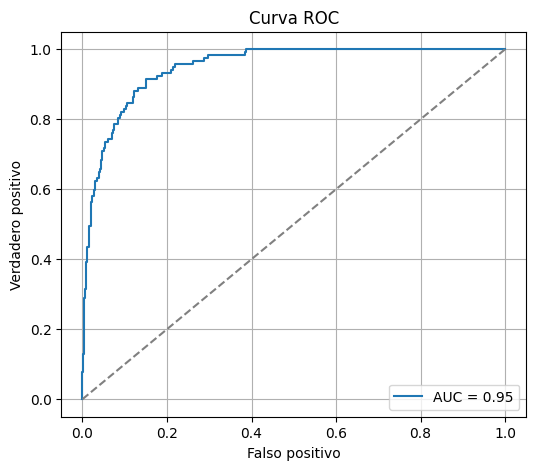

In [12]:
# Matriz de confusión
print("Matriz de confusión:")
print(confusion_matrix(df['y'], y_pred))

# Métricas
print("\nReporte de clasificación:")
print(classification_report(df['y'], y_pred))

# AUC y curva ROC
fpr, tpr, thresholds = roc_curve(df['y'], y_prob)
auc = roc_auc_score(df['y'], y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel('Falso positivo')
plt.ylabel('Verdadero positivo')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

La curva ROC es un gráfico que permite evaluar el rendimiento de un modelo de clasificación binario. Representa la tasa de verdaderos positivos repecto a los falsos positivos para diferentes umbrales
El AUC es el área bajo la curva y permite evaluar el desempeño del modelo:
* AUC = 0.5 (Adivina al azar)
* 0.5 < AUC < 0.8 Rendimiento aceptable o regular
* 0.8 < AUC < 0.9 Buen rendimiento 
* AUC > 0.9 Excelente capacidad 

### **Modelos de Poisson**
La variable dependiente y son datos de conteo no negativos de eventos raros e independientes
Asume que:
* Los eventos son independientes
* La tasa de ocurrencia de los eventos es constante en el tiempo o espacio
* La función de enlace es el logaritmo natural
* Resulta ser útil cuando en un número grande de ensayos independientes, son pocos los éxitos
* En una Poisson se asumen media y varianza iguales, por lo que es importante incluir la sobredispersión o la subdispersión.

**Sobredispersión:** La varianza de los datos es mayor a la media, es decir los datos muestran una mayor variabilidad que la que predice el modelo y el modelo puede subestimar la variabilidad en los datos. Una manera de arreglar esto es usar un modelo binomial negativo, que permite ajustar la varianza de manera independiente a la media

**Subdispersión:** Los datos presentan menor variabilidad que lo que predice Poisson, es decir que la varianza de los datos es menor a la media


In [13]:
# EJEMPLO DE IMPLEMENTACIÓN DE POISSON PARA PUNTOS CALIENTES DE INCENDIOS FORESTALES

# Librerías necesarias
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Crear un conjunto de datos simulado con pandas
data = {
    'temperatura': np.random.normal(30, 5, 100),  # Temperatura media en grados Celsius
    'humedad_relativa': np.random.uniform(20, 80, 100),  # Humedad relativa en porcentaje
    'ndvi': np.random.uniform(0.2, 0.9, 100),  # NDVI (densión de vegetación, entre 0 y 1)
    'puntos_calientes': np.random.poisson(3, 100)  # Número de puntos calientes detectados
}

# Convertir los datos en un DataFrame
df = pd.DataFrame(data)

# Describir los primeros datos del DataFrame
print(df.head())

   temperatura  humedad_relativa      ndvi  puntos_calientes
0    32.865639         23.014581  0.572018                 2
1    21.070668         22.094693  0.401562                 4
2    28.201852         53.069598  0.544974                 2
3    31.505537         46.290717  0.409959                 1
4    30.919173         70.350824  0.617257                 3


In [14]:
# Ajustar un modelo GLM de Poisson utilizando statsmodels
# La fórmula describe el modelo: puntos_calientes ~ temperatura + humedad_relativa + ndvi
modelo_poisson = smf.glm(formula="puntos_calientes ~ temperatura + humedad_relativa + ndvi", 
                         data=df, 
                         family=sm.families.Poisson()).fit()

# Resumen del modelo
print(modelo_poisson.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       puntos_calientes   No. Observations:                  100
Model:                            GLM   Df Residuals:                       96
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -184.92
Date:                Thu, 11 Jun 2026   Deviance:                       97.186
Time:                        19:57:32   Pearson chi2:                     85.2
No. Iterations:                     4   Pseudo R-squ. (CS):            0.03179
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.5558      0.429  

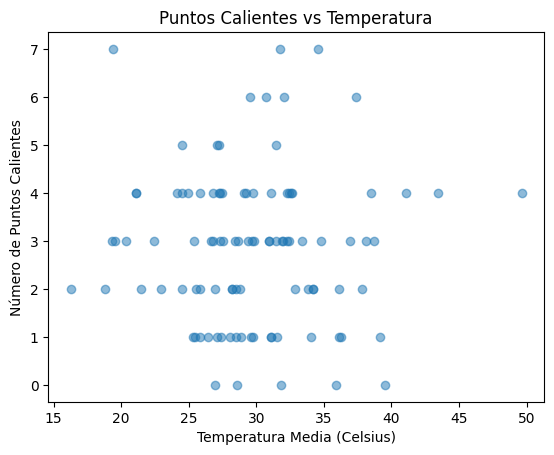

In [15]:
# Gráfico simple de puntos calientes vs temperatura para ilustrar la correlación
plt.scatter(df['temperatura'], df['puntos_calientes'], alpha=0.5)
plt.xlabel('Temperatura Media (Celsius)')
plt.ylabel('Número de Puntos Calientes')
plt.title('Puntos Calientes vs Temperatura')
plt.show()

### Ejemplo con cuencas

In [16]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families
from sklearn.preprocessing import StandardScaler

gdf = gpd.read_file(r"C:\Users\DAVID01\Documents\GitHub\Geospatial-analysis\ejercicios\df_catchments_spatial.gpkg")

# Preparar datos para regresión de Poisson con offset por área
y = gdf['lands_rec']
var = ['elev_mean', 'rel_mean']  # No incluimos 'area' como predictor directamente ahora
exposure = np.log(gdf['area'])  # Logaritmo del área como medida de exposición

# Escalar variables independientes (excepto el área que se usa como offset)
st = StandardScaler()
X_scaled = st.fit_transform(gdf[var])

# Añadir una constante para el término de intercepción
X = sm.add_constant(X_scaled)

# Entrenar el modelo de regresión de Poisson con offset
poisson_model_offset = GLM(y, X, family=families.Poisson(), offset=exposure).fit()

# Imprimir un resumen del modelo de regresión de Poisson con offset
print(poisson_model_offset.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              lands_rec   No. Observations:                  526
Model:                            GLM   Df Residuals:                      523
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6974.2
Date:                Thu, 11 Jun 2026   Deviance:                       12334.
Time:                        19:57:32   Pearson chi2:                 1.79e+04
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -15.5307      0.013  -1210.076      0.0

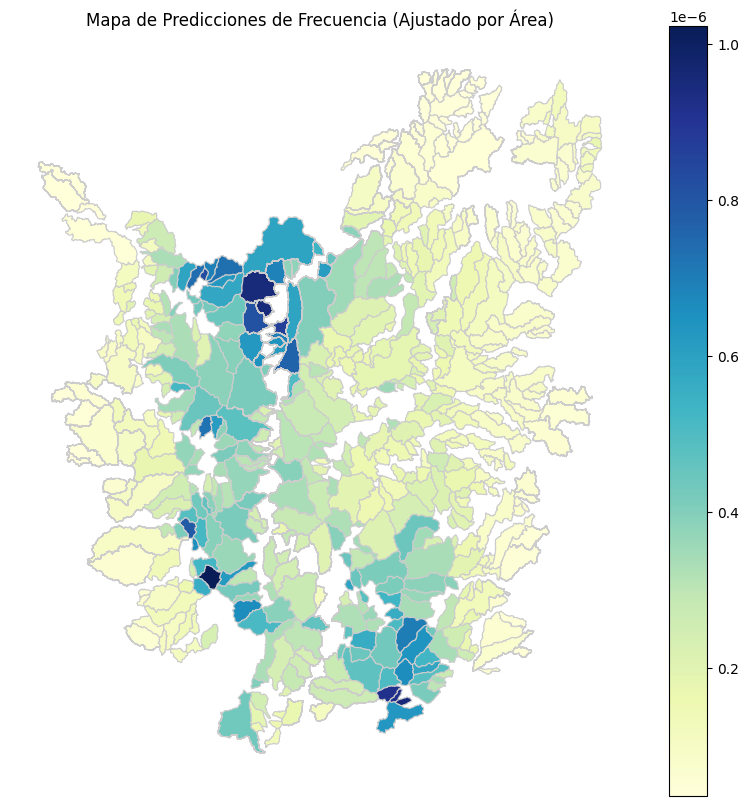

In [17]:
# Obtener las predicciones de frecuencia (ahora representan la frecuencia ajustada por el área)
y_pred_freq_offset = poisson_model_offset.predict(X)

# Añadir las predicciones al GeoDataFrame
gdf['predicted_lands_rec_offset'] = y_pred_freq_offset

# Calcular la diferencia entre el valor real y la predicción con offset
gdf['difference_lands_rec_offset'] = gdf['lands_rec'] - gdf['predicted_lands_rec_offset']

# Graficar el mapa con los valores de predicción de frecuencia ajustados por área
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='predicted_lands_rec_offset', cmap='YlGnBu', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Mapa de Predicciones de Frecuencia (Ajustado por Área)')
ax.set_axis_off()
plt.show()

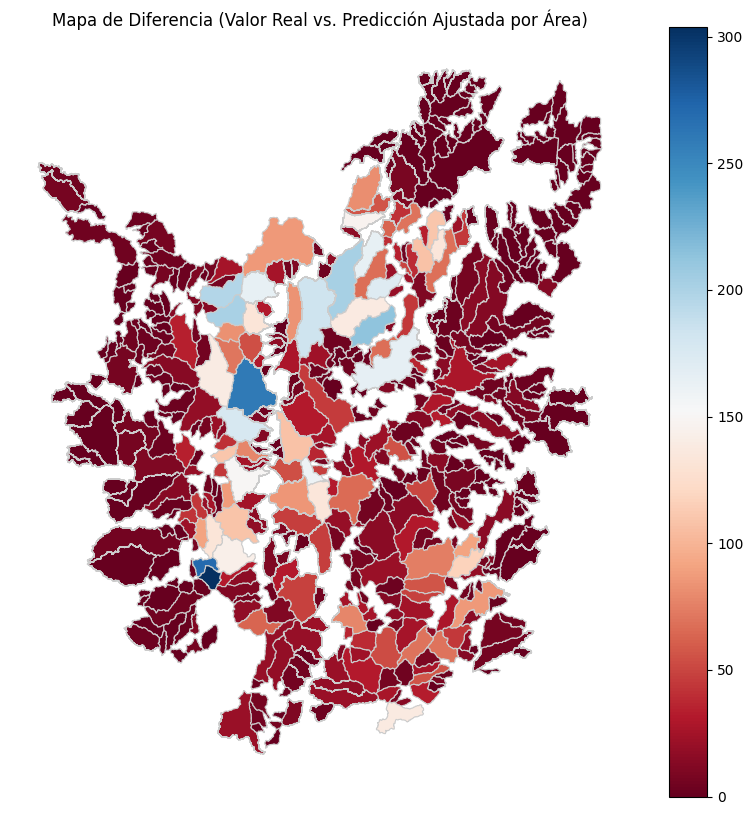

In [18]:
# Graficar el mapa con la diferencia entre el valor real y la predicción ajustada por área
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='difference_lands_rec_offset', cmap='RdBu', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Mapa de Diferencia (Valor Real vs. Predicción Ajustada por Área)')
ax.set_axis_off()
plt.show()